In [1]:
import pickle
import numpy as np 

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from pathlib import Path
import pandas as pd

### Get Saved Activations & Params

In [2]:
act_files = Path('../attentional_gain_activations/').glob('*.pkl')

In [3]:
acts = {}
for file in act_files:
    model = file.as_posix().split('pretrain_')[-1].split("_bs")[0]
    if 'bs' in model:
        model = 'unconstrained'
    if 'audset' in model:
        model = 'audioset'
        
    with open(file, 'rb') as f:
        acts[model] = pickle.load(f)

### Make DF for easy plotting

In [4]:
dfs = []

for model in acts.keys():
    model_dfs = []
    for layer in acts[model]['cue_acts'].keys():
        layer_dict = {'cue_acts': acts[model]['cue_acts'][layer],
                    'gain_acts': acts[model]['gain_acts'][layer],
                    'layer':[f"{layer}"] * len(acts[model]['cue_acts'][layer]),
                    'model':[f"{model}"] * len(acts[model]['cue_acts'][layer])}
        layer_df = pd.DataFrame.from_dict(layer_dict)
        model_dfs.append(layer_df)
    model_df = pd.concat(model_dfs)
    dfs.append(model_df)


In [5]:
act_df = pd.concat(dfs).reset_index()
act_df

,index,cue_acts,gain_acts,layer,model
0,0,-0.520996,0.327393,attn_block_in,audioset
1,1,-0.351562,0.377686,attn_block_in,audioset
2,2,-0.024673,0.481445,attn_block_in,audioset
3,3,0.172729,0.545898,attn_block_in,audioset
4,4,0.281006,0.580566,attn_block_in,audioset
...,...,...,...,...,...
11155995,307195,0.000000,0.696289,attn_block6,pos_slope
11155996,307196,0.000000,0.696289,attn_block6,pos_slope
11155997,307197,0.000000,0.696289,attn_block6,pos_slope
11155998,307198,0.013672,0.697266,attn_block6,pos_slope


In [6]:
act_df.model.unique()

array(['audioset', 'unconstrained', 'norm_at_input',
       'norm_at_input_pos_slope', 'pos_slope'], dtype=object)

In [7]:
# rename models for plots
act_df['model'].replace('unconstrained','no input LN',inplace=True)
act_df['model'].replace('pos_slope','no input LN positive slope',inplace=True)
act_df['model'].replace('norm_at_input','input LN',inplace=True)
act_df['model'].replace('norm_at_input_pos_slope','input LN positive slope',inplace=True)

In [8]:
act_df.model.unique()

array(['audioset', 'no input LN', 'input LN', 'input LN positive slope',
       'no input LN positive slope'], dtype=object)

In [27]:
## Set colormaps for plots:

model_names = act_df.model.unique()

no_ln = [name for name in model_names if 'no' in name]
ln = [name for name in model_names if 'no' not in name and 'audioset' not in name]
# green to purple map 
cmap =  sns.diverging_palette(150, 275, s=80, l=55, n=5, as_cmap=False)
no_ln_colors = cmap[:2]
ln_colors = cmap[-2:][::-1]

model_palette = dict(zip(no_ln + ln, no_ln_colors + ln_colors))

# get
hue_order = list(model_palette.keys())


In [28]:
model_palette

{'no input LN': (0.2295343431796616, 0.5768599765515849, 0.42976558041005153),
 'no input LN positive slope': (0.5810320906847469,
  0.7667224769463337,
  0.6862101460214469),
 'input LN': (0.5760948627700936, 0.42953354153177087, 0.9000298862470925),
 'input LN positive slope': (0.759071389226404,
  0.6845257804678868,
  0.9250019519010586)}

## Unbox gains to plot

In [29]:
model_name_dict = {'unconstrained':'no input LN',
            'pos_slope':'no input LN positive slope',
            'norm_at_input':'input LN',
            'norm_at_input_pos_slope':'input LN positive slope',
            'audioset':'audioset'}

model_map = {v:k for k,v in model_name_dict.items()}
gain_params = {}

for layer in act_df.layer.unique():
    gain_params[layer] = {}
    for model in model_name_dict.keys():
        gain_params[layer][model_name_dict[model]] = acts[model]['gain_params'][layer]

In [30]:
gain_params[layer].keys()

dict_keys(['no input LN', 'no input LN positive slope', 'input LN', 'input LN positive slope', 'audioset'])

In [31]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def attn_gain(x, bias, slope, threshold):
    return bias + (1-bias) * sigmoid((x - threshold) * slope)
    

In [32]:
def get_sigmoid(acts, model, layer, n_bins):
    gain_fn_params = acts[model]['gain_params'][layer]
    cue_acts = acts[model]['cue_acts'][layer]
    
    x_for_fn = np.linspace(cue_acts.min(), cue_acts.max(), n_bins)
    bias = gain_fn_params['bias']
    slope = gain_fn_params['slope']
    threshold = gain_fn_params['threshold']
    
    return attn_gain(x_for_fn, bias, slope, threshold).T
    
        

In [33]:
# sigmoids = np.array([get_sigmoid(acts, model, 'attn_block_in', 100) for model in acts.keys()])
sigmoids = {model_name_dict[model]:get_sigmoid(acts, model, 'attn_block_in', 100) for model in acts.keys()}


In [34]:
# sigmoids
hue_order

['no input LN',
 'no input LN positive slope',
 'input LN',
 'input LN positive slope']

In [35]:
np.array(list(sigmoids.values())).T.shape

(100, 5)

## Make Plots comparing gains of single talker models

no input LN
no input LN positive slope
input LN
input LN positive slope


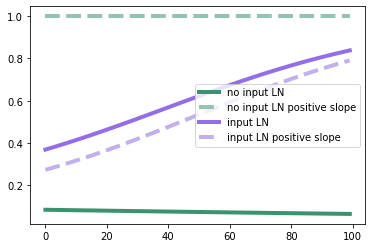

In [36]:
for model in hue_order:
    print(model)
    if model =='audioset':
        continue
    plt.plot(sigmoids[model], linewidth=4, color=model_palette[model], linestyle='--' if 'slope' in model else '-',
            label=model)
plt.legend()


KeyboardInterrupt



Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x2b082833b280> (for post_execute):


KeyboardInterrupt: 

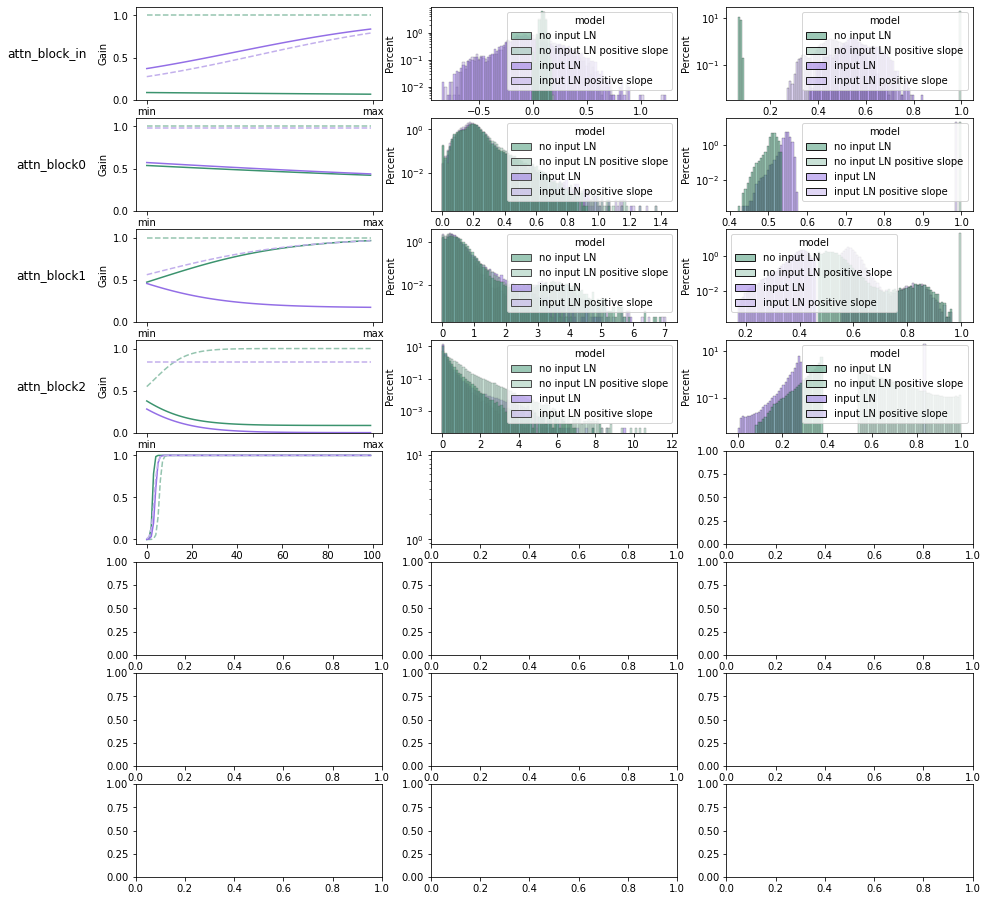

In [37]:
http://localhost:1337/notebooks/notebooks/2022_07_30_Make_Attentional_Gain_Plots.ipynb#
# Look at inputs to gain functions 
fig, axs = plt.subplots(8,3, figsize=(15,16))
# axs = axs.ravel()

n_hist_bins = 100
pad = 8

layer_names = act_df.layer.unique()

x_for_sigmoid = np.arange(n_hist_bins)

for ix, layer in enumerate(layer_names):

    # Plot filters 
    sigmoids = {model_name_dict[model]:get_sigmoid(acts, model, layer, n_hist_bins) for model in acts.keys()}    
    for model in hue_order:
        axs[ix,0].plot(sigmoids[model], color=model_palette[model],
                      linestyle='--' if 'slope' in model else '-',
                      label=model) # linewidth=4,

    # plot hist of cue activations    
    sns.histplot(data=act_df[act_df.layer == layer], x='cue_acts',
             stat='percent',  log_scale=(False, True), edgecolor='0.3',
             hue='model', hue_order=hue_order, palette=model_palette,
             bins=n_hist_bins, ax=axs[ix,1])

    # plot hist of gains
    sns.histplot(data=act_df[act_df.layer == layer], x='gain_acts',
                 stat='percent',  log_scale=(False, True), edgecolor='0.1',
                 hue='model', hue_order=hue_order, palette=model_palette,
                 bins=n_hist_bins, ax=axs[ix,2])
    
    axs[ix,0].annotate(layer, xy=(0, 0.5), xytext=(-axs[ix,0].yaxis.labelpad - pad, 0),
                xycoords=axs[ix,0].yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
    
    
    axs[ix,0].set_ylabel("Gain")
    axs[ix,0].set_xlabel("Relative activation magnitude")
    axs[ix,0].set_xticks([0,100])
    axs[ix,0].set_xticklabels(["min", "max"])
    axs[ix,0].set_ylim(0,1.1)

    axs[ix,1].set_xlabel("Activation magnitude")
    axs[ix,2].set_xlabel("Gain")
    
axs[0,0].set_title("Gain over range of pre-gain activations", y=1.2)
axs[0,1].set_title("Cue activations pre-gain", y=1.2)
axs[0,2].set_title("Gain activations", y=1.2)



axs[0,0].legend(loc="upper right", bbox_to_anchor=(4.25, 1))
axs[0,1].get_legend().remove()
axs[0,2].get_legend().remove()

for ax in axs[1:,1:].ravel():
    ax.get_legend().remove()
        

# plt.suptitle('LayerNorm after Cochleagram - Constrained Slope', y=1)


# plt.tight_layout()

## Make plot comparing Audioset Gains to Single Talker Gains

In [42]:
df_for_plot = act_df[act_df.model.str.contains('audioset|input LN positive slope')]

In [54]:
df_for_plot['model'].replace('input LN positive slope','single-talker',inplace=True)


df_for_plot = df_for_plot[df_for_plot['model'] != 'no input LN positive slope']

/tmp/ipykernel_42613/443977824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_plot['model'].replace('input LN positive slope','single-talker',inplace=True)


In [55]:
df_for_plot.model.unique()

array(['audioset', 'single-talker'], dtype=object)

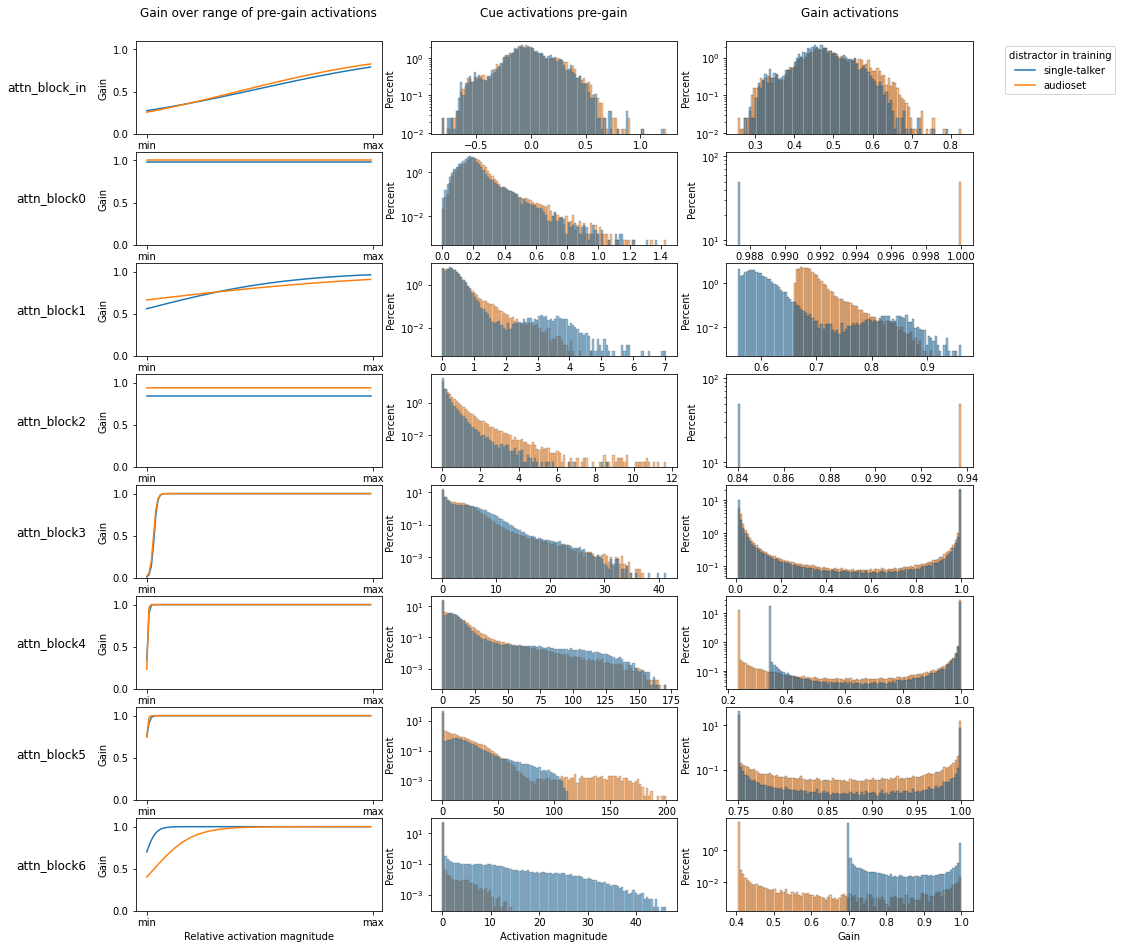

In [61]:
comp_hue_order = ['single-talker', 'audioset']

comp_model_palette = {"audioset":"tab:orange", 
                       "single-talker":"tab:blue"}



comp_name_dict = {
            'norm_at_input_pos_slope':'single-talker',
            'audioset':'audioset'}



# Look at inputs to gain functions 
fig, axs = plt.subplots(8,3, figsize=(15,16))
# axs = axs.ravel()

n_hist_bins = 100
pad = 8

layer_names = df_for_plot.layer.unique()

x_for_sigmoid = np.arange(n_hist_bins)

for ix, layer in enumerate(layer_names):

    # Plot filters 
    sigmoids = {comp_name_dict[model]:get_sigmoid(acts, model, layer, n_hist_bins)
                for model in acts.keys() if model in comp_name_dict.keys()}    
    for model in comp_hue_order:
        axs[ix,0].plot(sigmoids[model], color=comp_model_palette[model],
                      linestyle='--' if 'slope' in model else '-',
                      label=model) # linewidth=4,

    # plot hist of cue activations    
    sns.histplot(data=df_for_plot[df_for_plot.layer == layer], x='cue_acts',
             stat='percent',  log_scale=(False, True), edgecolor='0.3',
             hue='model', hue_order=comp_hue_order, palette=comp_model_palette,
             bins=n_hist_bins, ax=axs[ix,1])

    # plot hist of gains
    sns.histplot(data=df_for_plot[df_for_plot.layer == layer], x='gain_acts',
                 stat='percent',  log_scale=(False, True), edgecolor='0.1',
                 hue='model', hue_order=comp_hue_order, palette=comp_model_palette,
                 bins=n_hist_bins, ax=axs[ix,2])
    
    axs[ix,0].annotate(layer, xy=(0, 0.5), xytext=(-axs[ix,0].yaxis.labelpad - pad, 0),
                xycoords=axs[ix,0].yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
    
    
    axs[ix,0].set_ylabel("Gain")
    axs[ix,0].set_xlabel("Relative activation magnitude")
    axs[ix,0].set_xticks([0,100])
    axs[ix,0].set_xticklabels(["min", "max"])
    axs[ix,0].set_ylim(0,1.1)

    axs[ix,1].set_xlabel("Activation magnitude")
    axs[ix,2].set_xlabel("Gain")
    
axs[0,0].set_title("Gain over range of pre-gain activations", y=1.2)
axs[0,1].set_title("Cue activations pre-gain", y=1.2)
axs[0,2].set_title("Gain activations", y=1.2)



axs[0,0].legend(title='distractor in training', loc="upper right", bbox_to_anchor=(4, 1))
axs[0,1].get_legend().remove()
axs[0,2].get_legend().remove()

for ax in axs[1:,1:].ravel():
    ax.get_legend().remove()
        

# plt.suptitle('Attentional gains  ', y=1)


# plt.tight_layout()